# Benchmark Figures — DUC, DUC-S, DUC-M

Reads pre-aggregated CSVs from `../experiments/experiment_results_duc/`.  
Generates two sets of 4 figures:
- **DUC + DUC-S** only  
- **DUC + DUC-S + DUC-M**

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = '../experiments/experiment_results_duc'

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         13,
    'axes.titlesize':    14,
    'axes.labelsize':    13,
    'legend.fontsize':   12,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.35,
    'grid.linestyle':    '--',
})

COLORS  = {'DUC': '#1397b4', 'DUCT': '#4285f4', 'DUCM': '#9900ff'}
MARKERS = {'DUC': 'o',       'DUCT': 's',        'DUCM': '^'}


def plot_duc_benchmark(csv_file, x_col, xlabel, title, out_name, algorithms):
    """Plot avg_elapsed ± std_elapsed for the given algorithm subset and save as PNG."""
    df = pd.read_csv(os.path.join(RESULTS_DIR, csv_file))
    df = df[df['algorithm'].isin(algorithms)]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for alg, grp in df.groupby('algorithm'):
        grp = grp.sort_values(x_col)
        ax.plot(grp[x_col], grp['avg_elapsed'],
                marker=MARKERS[alg], color=COLORS[alg],
                linewidth=1.8, markersize=5, label=alg)
        ax.fill_between(grp[x_col],
                         (grp['avg_elapsed'] - grp['std_elapsed']).clip(lower=0),
                         grp['avg_elapsed'] + grp['std_elapsed'],
                         alpha=0.15, color=COLORS[alg])

    ax.set_xlabel(xlabel)
    ax.set_ylabel('mean runtime (s)')
    ax.set_title(title)
    ax.legend(framealpha=0.9)

    plt.tight_layout()
    out_path = os.path.join(RESULTS_DIR, out_name)
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out_path}')

---
## DUC vs DUC-T

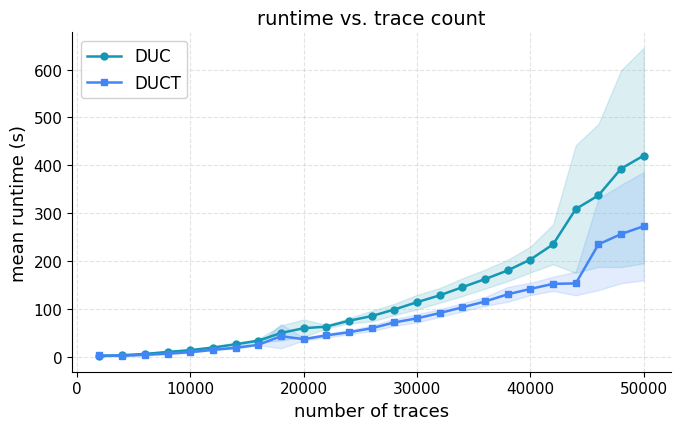

Saved → ../experiments/experiment_results_duc/fig_duc_ducs_trace_count.png


In [5]:
plot_duc_benchmark(
    csv_file   = 'avg_sample_size_results.csv',
    x_col      = 'sample_size',
    xlabel     = 'number of traces',
    title      = 'runtime vs. trace count',
    out_name   = 'fig_duc_ducs_trace_count.png',
    algorithms = ['DUC', 'DUCT'],
)

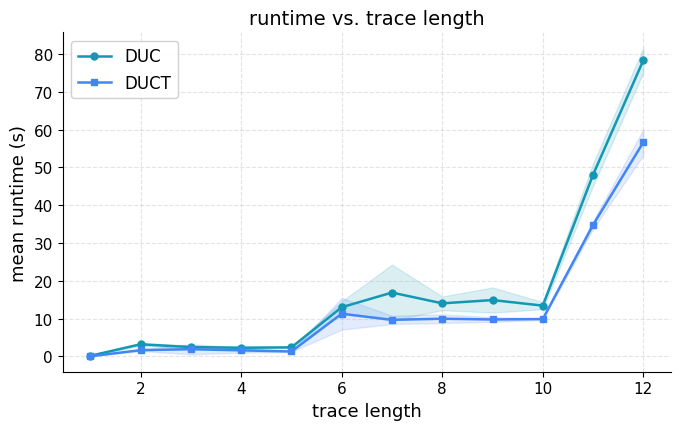

Saved → ../experiments/experiment_results_duc/fig_duc_ducs_trace_length.png


In [3]:
plot_duc_benchmark(
    csv_file   = 'avg_trace_length_results.csv',
    x_col      = 'trace_length',
    xlabel     = 'trace length',
    title      = 'runtime vs. trace length',
    out_name   = 'fig_duc_ducs_trace_length.png',
    algorithms = ['DUC', 'DUCT'],
)

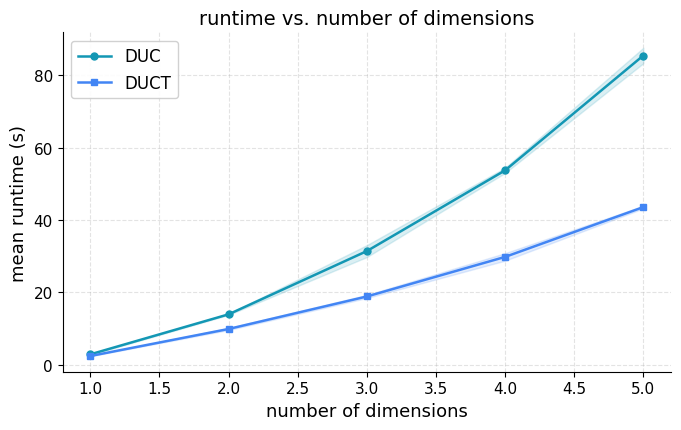

Saved → ../experiments/experiment_results_duc/fig_duc_ducs_dimensions.png


In [5]:
plot_duc_benchmark(
    csv_file   = 'avg_dimension_results.csv',
    x_col      = 'event_dimension',
    xlabel     = 'number of dimensions',
    title      = 'runtime vs. number of dimensions',
    out_name   = 'fig_duc_ducs_dimensions.png',
    algorithms = ['DUC', 'DUCT'],
)

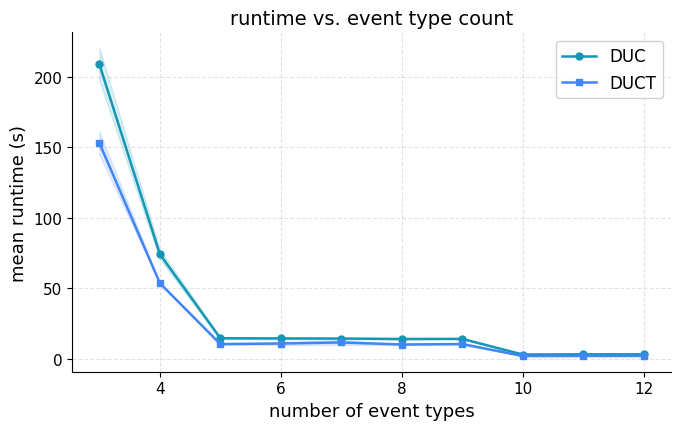

Saved → ../experiments/experiment_results_duc/fig_duc_ducs_type_count.png


In [4]:
plot_duc_benchmark(
    csv_file   = 'avg_type_count_results.csv',
    x_col      = 'type_count',
    xlabel     = 'number of event types',
    title      = 'runtime vs. event type count',
    out_name   = 'fig_duc_ducs_type_count.png',
    algorithms = ['DUC', 'DUCT'],
)

---
## DUC vs DUC-S vs DUC-M

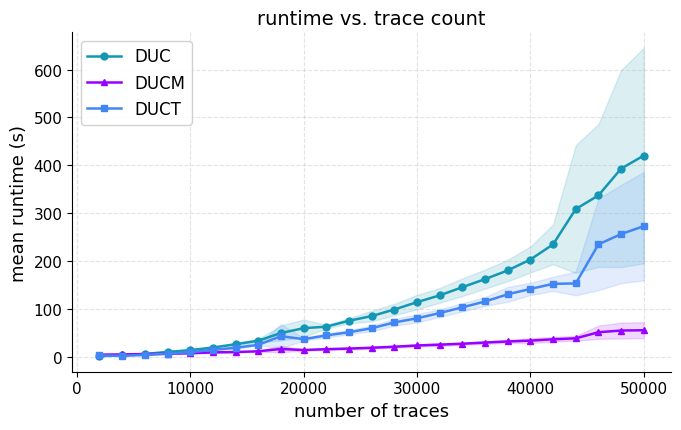

Saved → ../experiments/experiment_results_duc/fig_ducm_trace_count.png


In [6]:
plot_duc_benchmark(
    csv_file   = 'avg_sample_size_results.csv',
    x_col      = 'sample_size',
    xlabel     = 'number of traces',
    title      = 'runtime vs. trace count',
    out_name   = 'fig_ducm_trace_count.png',
    algorithms = ['DUC', 'DUCT', 'DUCM'],
)

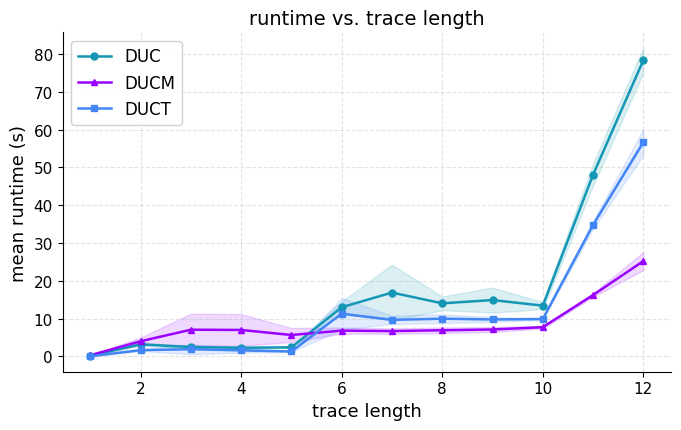

Saved → ../experiments/experiment_results_duc/fig_ducm_trace_length.png


In [7]:
plot_duc_benchmark(
    csv_file   = 'avg_trace_length_results.csv',
    x_col      = 'trace_length',
    xlabel     = 'trace length',
    title      = 'runtime vs. trace length',
    out_name   = 'fig_ducm_trace_length.png',
    algorithms = ['DUC', 'DUCT', 'DUCM'],
)

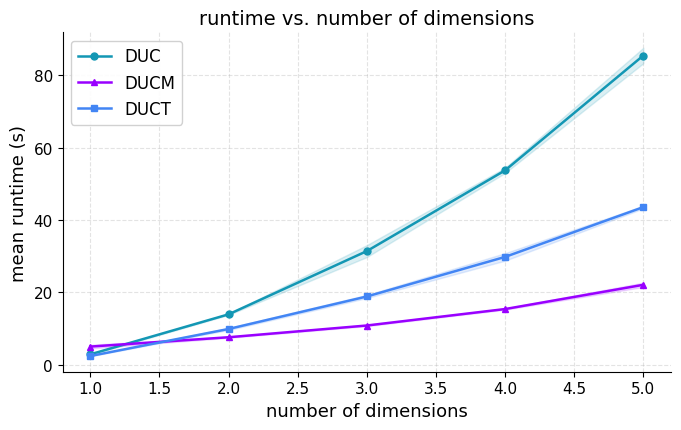

Saved → ../experiments/experiment_results_duc/fig_ducm_dimensions.png


In [8]:
plot_duc_benchmark(
    csv_file   = 'avg_dimension_results.csv',
    x_col      = 'event_dimension',
    xlabel     = 'number of dimensions',
    title      = 'runtime vs. number of dimensions',
    out_name   = 'fig_ducm_dimensions.png',
    algorithms = ['DUC', 'DUCT', 'DUCM'],
)

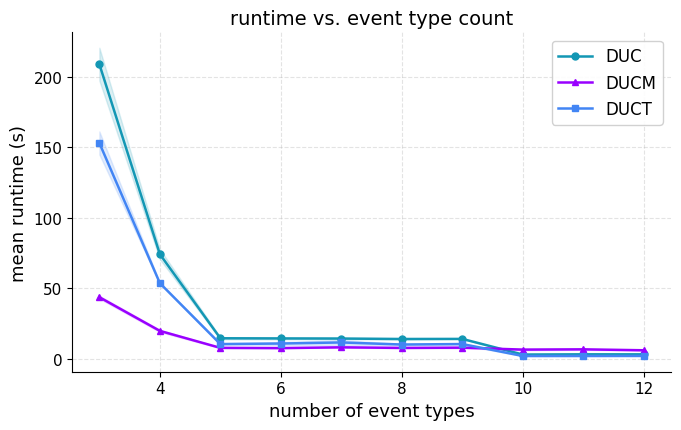

Saved → ../experiments/experiment_results_duc/fig_ducm_type_count.png


In [9]:
plot_duc_benchmark(
    csv_file   = 'avg_type_count_results.csv',
    x_col      = 'type_count',
    xlabel     = 'number of event types',
    title      = 'runtime vs. event type count',
    out_name   = 'fig_ducm_type_count.png',
    algorithms = ['DUC', 'DUCT', 'DUCM'],
)

---
## DUC vs DUCT vs DUCM-n vs DUCM-b

Reads the new per-repetition CSVs written by `benchmark.ipynb` (`duc_trace_count.csv`, `benchmark_duc_trace_length.csv`, `benchmark_duc_dimensions.csv`, `benchmark_duc_type_count.csv`) — a different schema from the pre-aggregated `avg_*_results.csv` files above (`time_s` per rep instead of pre-computed `avg_elapsed`/`std_elapsed`), and covers 4 algorithms including the two DUCM partitioning variants (DUCM-n = naive split, DUCM-b = length-balanced split).

In [6]:
COLORS_4  = {'D-U-C': '#1397b4', 'D-U-C-T': '#4285f4', 'D-U-C-M-r': '#e91e63', 'D-U-C-M-b': '#9900ff'}
MARKERS_4 = {'D-U-C': 'o',       'D-U-C-T': 's',        'D-U-C-M-r': 'D',       'D-U-C-M-b': '^'}
LABELS_4  = {'D-U-C': 'DUC',     'D-U-C-T': 'DUCT',     'D-U-C-M-r': 'DUCM-n',  'D-U-C-M-b': 'DUCM-b'}


def plot_benchmark_per_rep(csv_file, x_col, xlabel, title, out_name, colors, markers, labels=None, x_divisor=1):
    """Plot mean ± std runtime per algorithm from a per-repetition CSV (has a 'time_s' column) and save as PNG.

    labels: optional dict mapping the raw 'algorithm' CSV value to a display legend label.
    """
    df = pd.read_csv(os.path.join(RESULTS_DIR, csv_file))
    labels = labels or {}

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for alg, grp in df.groupby('algorithm'):
        stats = grp.groupby(x_col)['time_s'].agg(['mean', 'std']).reset_index()
        x = stats[x_col] / x_divisor
        ax.plot(x, stats['mean'],
                marker=markers[alg], color=colors[alg],
                linewidth=1.8, markersize=5, label=labels.get(alg, alg))
        ax.fill_between(x,
                         (stats['mean'] - stats['std']).clip(lower=0),
                         stats['mean'] + stats['std'],
                         alpha=0.15, color=colors[alg])

    ax.set_xlabel(xlabel)
    ax.set_ylabel('mean runtime (s)')
    ax.set_title(title)
    ax.legend(framealpha=0.9)

    plt.tight_layout()
    out_path = os.path.join(RESULTS_DIR, out_name)
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out_path}')

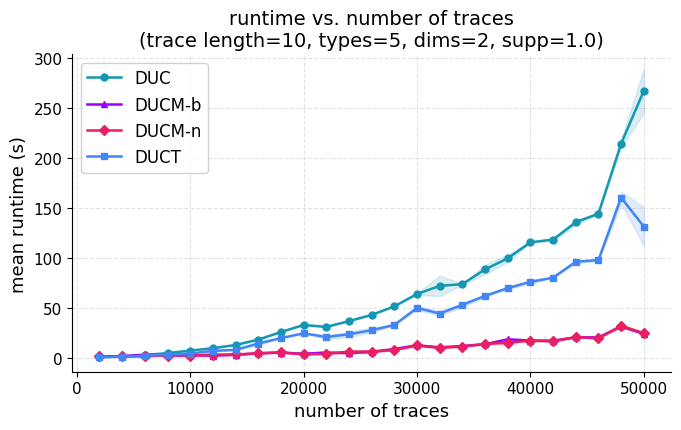

Saved → ../experiments/experiment_results_duc/fig_duc4_trace_count.png


In [7]:
plot_benchmark_per_rep(
    csv_file  = 'duc_trace_count.csv',
    x_col     = 'trace_count',
    xlabel    = 'number of traces',
    title     = 'runtime vs. number of traces\n(trace length=10, types=5, dims=2, supp=1.0)',
    out_name  = 'fig_duc4_trace_count.png',
    colors    = COLORS_4,
    markers   = MARKERS_4,
    labels    = LABELS_4,
)

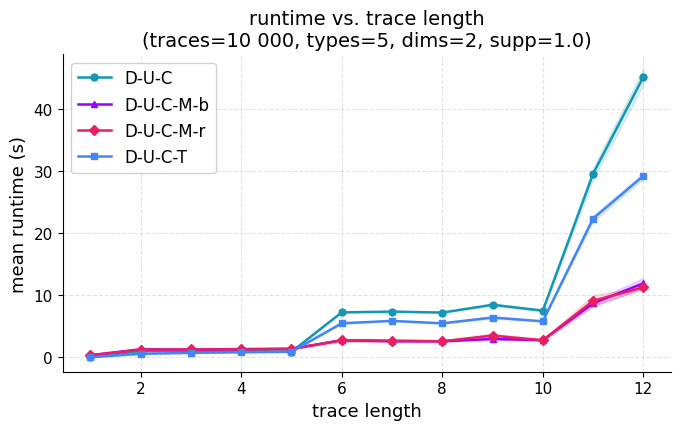

Saved → ../experiments/experiment_results_duc/fig_duc4_trace_length.png


In [8]:
plot_benchmark_per_rep(
    csv_file  = 'benchmark_duc_trace_length.csv',
    x_col     = 'trace_length',
    xlabel    = 'trace length',
    title     = 'runtime vs. trace length\n(traces=10 000, types=5, dims=2, supp=1.0)',
    out_name  = 'fig_duc4_trace_length.png',
    colors    = COLORS_4,
    markers   = MARKERS_4,
)

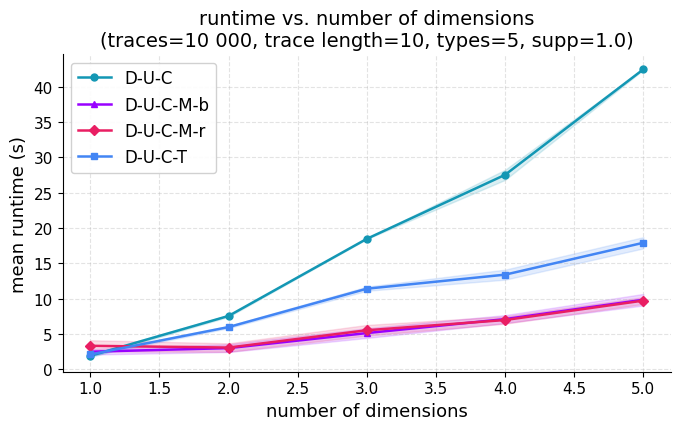

Saved → ../experiments/experiment_results_duc/fig_duc4_dimensions.png


In [13]:
plot_benchmark_per_rep(
    csv_file  = 'benchmark_duc_dimensions.csv',
    x_col     = 'dimensions',
    xlabel    = 'number of dimensions',
    title     = 'runtime vs. number of dimensions\n(traces=10 000, trace length=10, types=5, supp=1.0)',
    out_name  = 'fig_duc4_dimensions.png',
    colors    = COLORS_4,
    markers   = MARKERS_4,
)

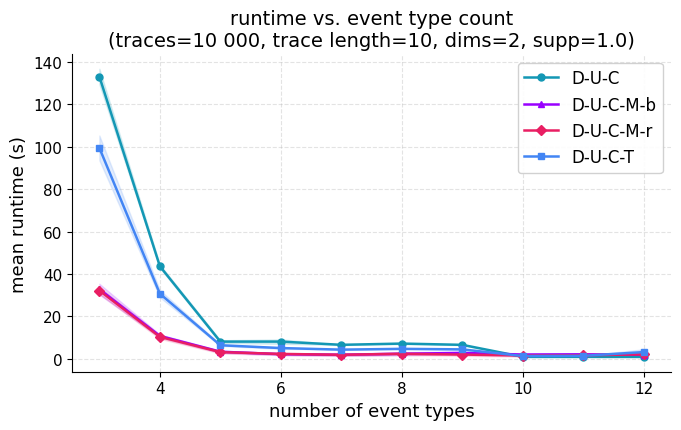

Saved → ../experiments/experiment_results_duc/fig_duc4_type_count.png


In [11]:
plot_benchmark_per_rep(
    csv_file  = 'benchmark_duc_type_count.csv',
    x_col     = 'type_count',
    xlabel    = 'number of event types',
    title     = 'runtime vs. event type count\n(traces=10 000, trace length=10, dims=2, supp=1.0)',
    out_name  = 'fig_duc4_type_count.png',
    colors    = COLORS_4,
    markers   = MARKERS_4,
)

---
## D-U-C-M-r vs D-U-C-M-b — widening trace-length spread

Reads `benchmark_ducm_max_trace_length.csv` (min trace length fixed at 2, max trace length varies).

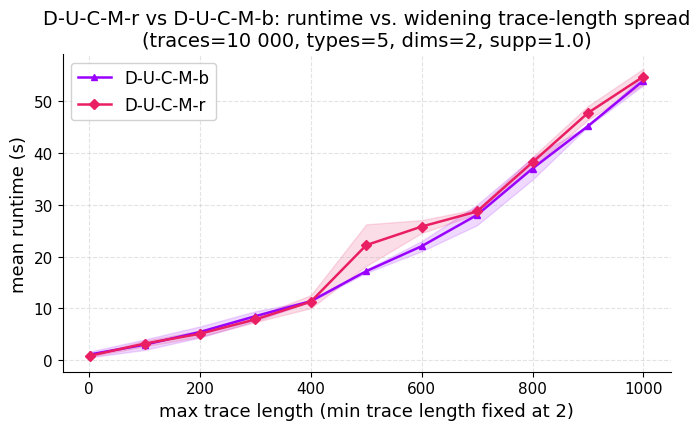

Saved → ../experiments/experiment_results_duc/fig_ducm_rb_max_trace_length.png


In [15]:
COLORS_RB  = {'D-U-C-M-r': COLORS_4['D-U-C-M-r'], 'D-U-C-M-b': COLORS_4['D-U-C-M-b']}
MARKERS_RB = {'D-U-C-M-r': MARKERS_4['D-U-C-M-r'], 'D-U-C-M-b': MARKERS_4['D-U-C-M-b']}

plot_benchmark_per_rep(
    csv_file  = 'benchmark_ducm_max_trace_length.csv',
    x_col     = 'max_trace_length',
    xlabel    = 'max trace length (min trace length fixed at 2)',
    title     = 'D-U-C-M-r vs D-U-C-M-b: runtime vs. widening trace-length spread\n(traces=10 000, types=5, dims=2, supp=1.0)',
    out_name  = 'fig_ducm_rb_max_trace_length.png',
    colors    = COLORS_RB,
    markers   = MARKERS_RB,
)